# 05 – Smoke-Check: drei Methoden auf echten Baumärkten

Sanity-Check der end-to-end gescorten Methoden (`evaluation/scoring.py`). Drei Ebenen:
**gespeichert** wird nativ (Punkt bzw. Segment-Tag), **angezeigt** wird gebroadcastet
(Segment als eingefärbtes Zeitfenster), **verglichen** wird auf Segment-Tag-Ebene.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from rausch_energy_anomaly.ingestion import rlm_loader as loader  # noqa: E402
from rausch_energy_anomaly.evaluation.scoring import pairwise_overlap, to_segment_day_grid  # noqa: E402

FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (13, 4), "axes.grid": True, "grid.alpha": 0.3})

scores = pd.read_parquet(ROOT / "data" / "processed" / "anomaly_scores.parquet")
scores["timestamp"] = pd.to_datetime(scores["timestamp"])
print("Scores:", scores.shape, "| Methoden:", sorted(scores["method"].unique()))
print((scores.groupby("method")["flag"].mean() * 100).round(2).rename("flag_%"))

Scores: (4551024, 7) | Methoden: ['arima', 'cluster_segment', 'zscore_stl']
method
arima              2.49
cluster_segment    0.86
zscore_stl         2.96
Name: flag_%, dtype: float64


## 1. Markierte Anomalien je Methode (ein Zeitfenster, ein Standort)

Punkt-Methoden (zscore_stl, arima) als rote Punkte auf dem Lastgang; cluster_segment als
eingefärbtes Segment-Fenster (Broadcast nur zur Anzeige). Fenster bewusst um Weihnachten
(Feiertags-Anomalien sichtbar).

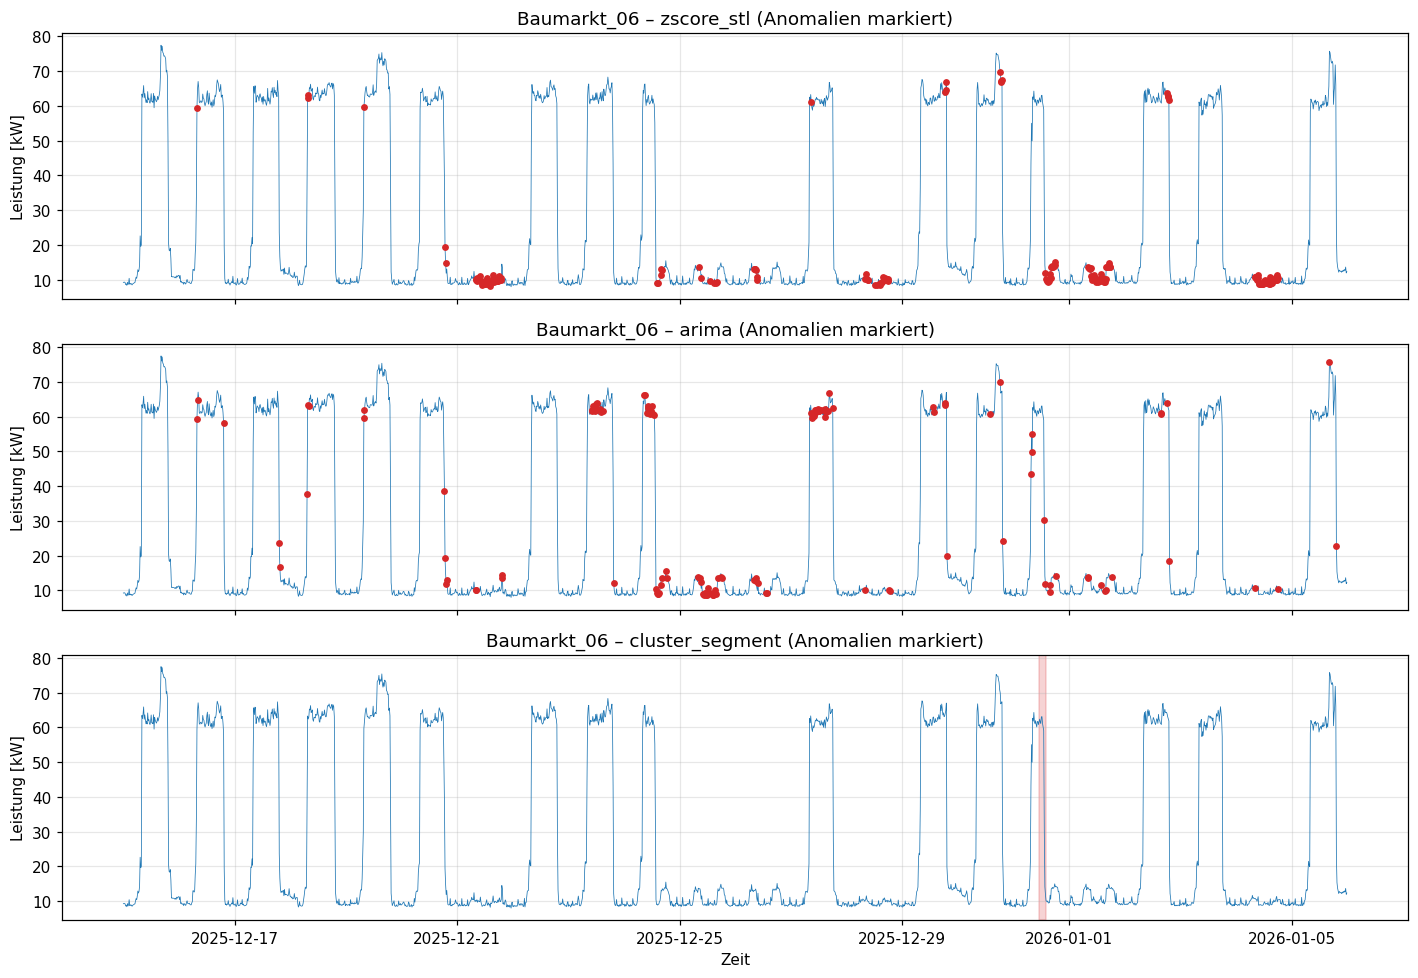

gespeichert: reports/figures/05_smoke_anomalien_je_methode.png


In [2]:
# Lastgang (value_kw) für den Plot-Standort laden
df = loader.load_category("Baumärkte")
SITE = "Baumarkt_06"  # repräsentativ (volle Abdeckung, solide Magnitude)
WIN = slice("2025-12-15", "2026-01-05")
load = df.xs(SITE, level="meter_id")["value_kw"].loc[WIN]

SEG_HOURS = {"nachts": (0, 6), "vormittag": (6, 11), "mittag": (11, 14), "nachmittag": (14, 22)}
sub = scores[(scores["site"] == SITE) & (scores["timestamp"] >= load.index.min()) & (scores["timestamp"] <= load.index.max())]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, method in zip(axes, ["zscore_stl", "arima", "cluster_segment"]):
    ax.plot(load.index, load.values, lw=0.5, color="tab:blue")
    m = sub[(sub["method"] == method) & sub["flag"]]
    if method == "cluster_segment":
        for _, r in m.iterrows():
            h0, h1 = SEG_HOURS[r["segment"]]
            day = pd.Timestamp(r["timestamp"]).normalize()
            ax.axvspan(day + pd.Timedelta(hours=h0), day + pd.Timedelta(hours=h1), color="tab:red", alpha=0.2)
    else:
        pts = load.reindex(m["timestamp"]).dropna()
        ax.scatter(pts.index, pts.values, color="tab:red", s=12, zorder=3)
    ax.set_title(f"{SITE} – {method} (Anomalien markiert)")
    ax.set_ylabel("Leistung [kW]")
axes[-1].set_xlabel("Zeit")
fig.tight_layout()
fig.savefig(FIG / "05_smoke_anomalien_je_methode.png", dpi=150, bbox_inches="tight")
plt.show()
print("gespeichert: reports/figures/05_smoke_anomalien_je_methode.png")

## 2. Informelle Overlap-Intuition (Segment-Tag-Ebene)

Erste Kappa-/Jaccard-Intuition – **auf Segment-Tag hoch-aggregiert**, nicht auf
gebroadcasteten Punkten (sonst verzerrt). Nicht der formale Schritt 11.

In [3]:
grid = to_segment_day_grid(scores)
ov = pairwise_overlap(grid)
print("Flag-Rate je Methode auf Segment-Tag-Ebene:")
print((grid.groupby("method")["flag"].mean() * 100).round(2).rename("flag_%"))
print()
ov.round(3)

Flag-Rate je Methode auf Segment-Tag-Ebene:
method
arima              29.92
cluster_segment     0.86
zscore_stl         14.06
Name: flag_%, dtype: float64



,method_a,method_b,jaccard,kappa,n
0,arima,cluster_segment,0.012,0.008,92968
1,arima,zscore_stl,0.384,0.450,92968
2,cluster_segment,zscore_stl,0.007,-0.003,92968


## 3. Befunde (Smoke)

- **Vollauf:** 23 Sites in **~7,3 min** (435 s), 4,55 Mio. Score-Zeilen → `anomaly_scores.parquet`.
  Die frühere 43-min-Schätzung war falsch (linear extrapoliert); `auto_arima` läuft pro
  Peer-Gruppe (3×, konstant), nicht pro Site. Bottlenecks: STL (~4,5 min) + auto_arima (3×).
- **Zwei Real-Data-Bugs gefunden & gefixt** (genau dafür „Verdrahtung zuerst"):
  (1) tz-naives `fit_end` vs. tz-aware 15-min-Index; (2) **Baumarkt_23** startet erst 2025 →
  leerer Train-Slice → Fallback auf die volle Site-Reihe (mit WARNING).
- **DST real:** Lauf über 3 Jahre × 23 Sites **ohne** Reindex-/DST-Fehler (Frühjahr-Lücke,
  Herbst-Duplikat sauber durch das tz-aware 15-min-Raster).
- **Flag-Raten nativ:** zscore_stl 2,96 % / arima 2,49 % (je 15-min-Punkt), cluster_segment
  0,86 % (je Segment-Tag).
- **Overlap (Segment-Tag, n=92.968):** zscore↔arima **κ≈0,45** (moderat – beide
  residual-basiert, plausibel); cluster↔beide **κ≈0** (nahezu disjunkt) → die Distanz-Methode
  erfasst ein **anderes** Signal (Segment-Form) und ist deutlich konservativer.
- **Aggregations-Artefakt (für Schritt 11 wichtig):** die „any-Flag-im-Segment"-Hoch-
  aggregation bläht die Punkt-Methoden auf Segment-Tag-Ebene auf (arima ~30 %, zscore ~14 %).
  Für die formale Kappa-Bewertung ggf. eine **Anteils-/Mindestdauer-Schwelle** statt „any"
  prüfen. (Hoch-aggregieren bleibt richtig; nur die Schwelle ist zu kalibrieren.)